<a href="https://colab.research.google.com/github/Antoninus90/ActividadEDA_JavierFregoso/blob/main/Actividad_grupal_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install openpyxl

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
MSE LR: 9.50678275091151
MSE NN: 8.320792100607303


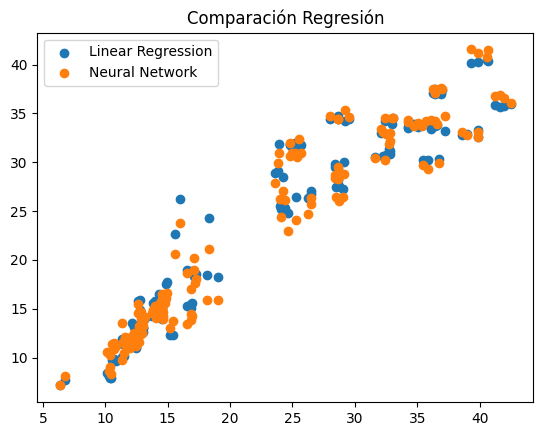

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

X = df.iloc[:, :-2]
y = df.iloc[:, -2]

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(X)

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Modelo clásico
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Red neuronal
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_reg.compile(optimizer='adam', loss='mse')
model_reg.fit(X_train, y_train, epochs=50, verbose=0)

y_pred_nn = model_reg.predict(X_test)

print("MSE LR:", mean_squared_error(y_test, y_pred_lr))
print("MSE NN:", mean_squared_error(y_test, y_pred_nn))

plt.scatter(y_test, y_pred_lr, label="Linear Regression")
plt.scatter(y_test, y_pred_nn, label="Neural Network")
plt.legend()
plt.title("Comparación Regresión")
plt.show()

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical

# Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# Discretizar
df['quality'] = pd.cut(df['quality'], bins=5, labels=False)

X = df.drop('quality', axis=1)
y = df['quality']

# Normalizar
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot
y_cat = to_categorical(y)

# División
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2)

# Modelo clásico
rf = RandomForestClassifier()
rf.fit(X_train, np.argmax(y_train, axis=1))
y_pred_rf = rf.predict(X_test)

# Red neuronal
model_clf = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')
])

model_clf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_clf.fit(X_train, y_train, epochs=50, verbose=0)

loss, acc = model_clf.evaluate(X_test, y_test)

print("Accuracy RF:", accuracy_score(np.argmax(y_test, axis=1), y_pred_rf))
print("Accuracy NN:", acc)

cm = confusion_matrix(np.argmax(y_test, axis=1), y_pred_rf)
print("Confusion Matrix:\n", cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5594 - loss: 0.9675  
Accuracy RF: 0.659375
Accuracy NN: 0.559374988079071
Confusion Matrix:
 [[ 0 10  2  0  0]
 [ 0 92 37  3  0]
 [ 0 33 93  7  0]
 [ 0  1 12 25  0]
 [ 0  0  0  4  1]]


In [18]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

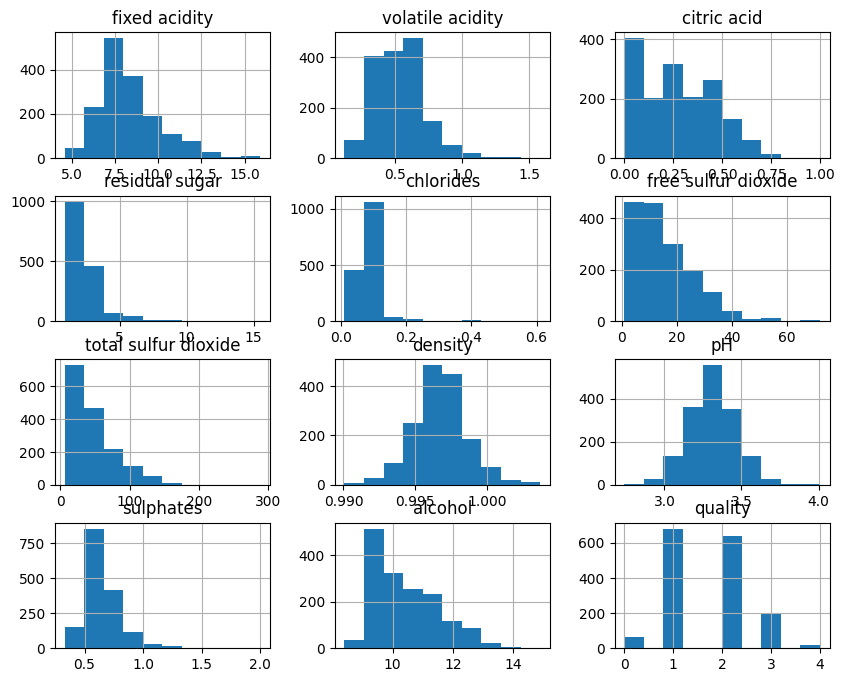

In [19]:
import matplotlib.pyplot as plt
df.hist(figsize=(10,8))
plt.show()